In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
import urllib.request
import os

# Download the Online Shoppers Intention dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
save_path = "../data/ecommerce_sales_data.csv"

print("Downloading dataset...")
urllib.request.urlretrieve(url, save_path)
print("Dataset downloaded successfully")

Dataset downloaded successfully


In [3]:
# Load the dataset and take a first look
df = pd.read_csv("../data/ecommerce_sales_data.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (12330, 18)

First 5 rows:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00  

In [5]:
# Data Preprocessing
# Drop columns that aren't useful for prediction
df.drop(columns=['Administrative', 'Informational', 'ProductRelated'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
df['Weekend'] = le.fit_transform(df['Weekend'])
df['Revenue'] = le.fit_transform(df['Revenue'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Month'] = le.fit_transform(df['Month'])

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before - after} duplicate rows")

# Scale continuous features
scaler = MinMaxScaler()
scale_cols = ['Administrative_Duration', 'Informational_Duration',
              'ProductRelated_Duration', 'BounceRates',
              'ExitRates', 'PageValues', 'SpecialDay']

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Preprocessing complete")
print("Dataset shape after cleaning:", df.shape)


Removed 173 duplicate rows
Preprocessing complete
Dataset shape after cleaning: (12157, 15)


C:\Users\Naveeth Ahamed\AppData\Local\Temp\ipykernel_17780\3816826794.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='Set2')


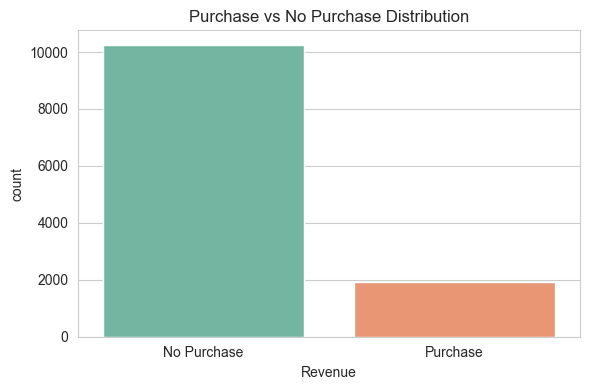

Chart 1 done


C:\Users\Naveeth Ahamed\AppData\Local\Temp\ipykernel_17780\3816826794.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Blues')


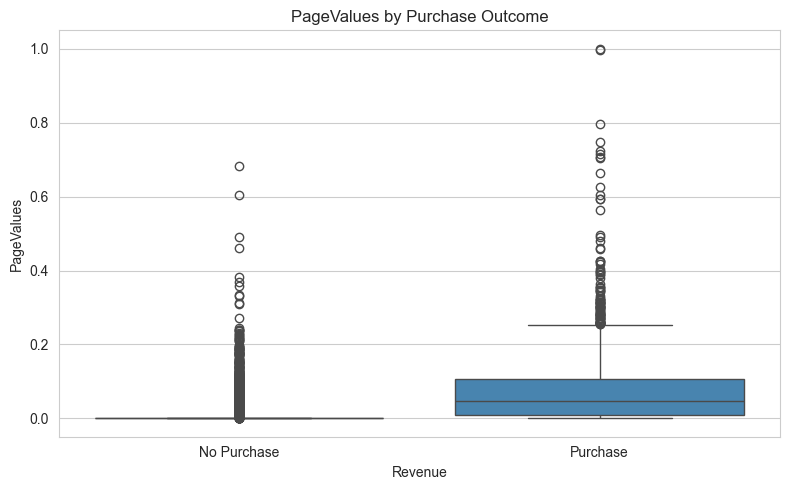

Chart 2 done


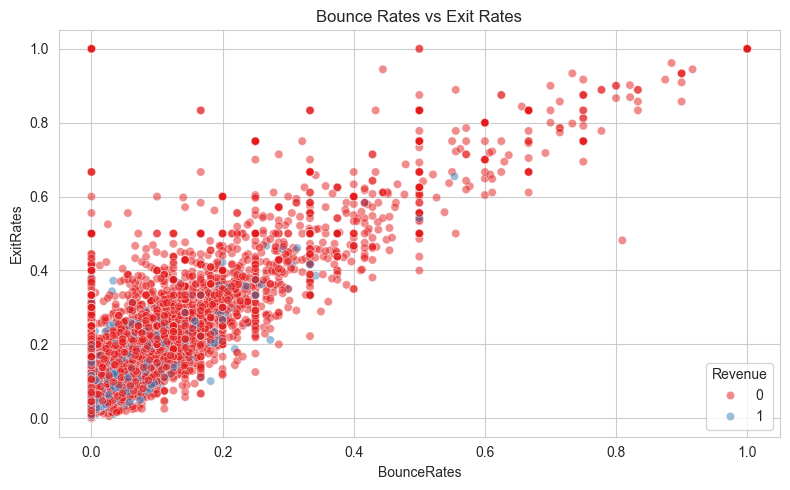

Chart 3 done


In [6]:
# Exploratory Data Analysis
# Let's understand the data before building models

sns.set_style("whitegrid")

# Chart 1 — Revenue distribution (how balanced is our target?)
plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df, palette='Set2')
plt.title('Purchase vs No Purchase Distribution')
plt.xticks([0,1], ['No Purchase', 'Purchase'])
plt.tight_layout()
plt.savefig('../outputs/revenue_distribution.png', dpi=150)
plt.show()
print("Chart 1 done")

# Chart 2 — PageValues vs Revenue (strongest predictor)
plt.figure(figsize=(8,5))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Blues')
plt.title('PageValues by Purchase Outcome')
plt.xticks([0,1], ['No Purchase', 'Purchase'])
plt.tight_layout()
plt.savefig('../outputs/pagevalues_vs_revenue.png', dpi=150)
plt.show()
print("Chart 2 done")

# Chart 3 — Bounce rates vs Exit rates
plt.figure(figsize=(8,5))
sns.scatterplot(x='BounceRates', y='ExitRates', hue='Revenue', data=df, alpha=0.5, palette='Set1')
plt.title('Bounce Rates vs Exit Rates')
plt.tight_layout()
plt.savefig('../outputs/bounce_vs_exit.png', dpi=150)
plt.show()
print("Chart 3 done")

In [7]:
# Prepare features and target variable
X = df.drop('Revenue', axis=1)
y = df['Revenue']

print("Class distribution before SMOTE:")
print(y.value_counts())

# Apply SMOTE to fix class imbalance
# Our dataset has way more non-purchases than purchases
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Class distribution before SMOTE:
Revenue
0    10249
1     1908
Name: count, dtype: int64

Class distribution after SMOTE:
Revenue
0    10249
1    10249
Name: count, dtype: int64

Training set size: (16398, 14)
Testing set size: (4100, 14)


In [8]:
# Train and compare multiple classification models
# We want to find the best one for predicting purchases

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f} ({acc*100:.1f}%)")

print("\nBest model:", max(results, key=results.get))

Logistic Regression: 0.8420 (84.2%)
Decision Tree: 0.8744 (87.4%)
Random Forest: 0.9220 (92.2%)
Extra Trees: 0.9385 (93.9%)

Best model: Extra Trees


FINAL MODEL: Extra Trees Classifier
Accuracy: 93.9%

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.96      0.92      0.94      2050
    Purchase       0.92      0.96      0.94      2050

    accuracy                           0.94      4100
   macro avg       0.94      0.94      0.94      4100
weighted avg       0.94      0.94      0.94      4100



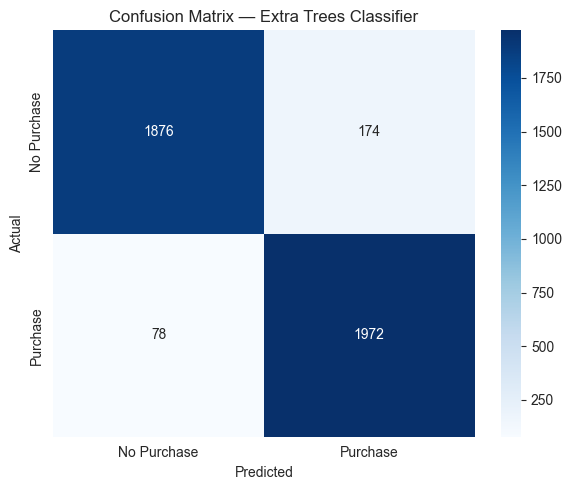

Confusion matrix saved


In [9]:
# Final model evaluation — Extra Trees is our winner
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)
y_pred = et.predict(X_test)

print("FINAL MODEL: Extra Trees Classifier")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

# Confusion matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix — Extra Trees Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved")

C:\Users\Naveeth Ahamed\AppData\Local\Temp\ipykernel_17780\3222264753.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


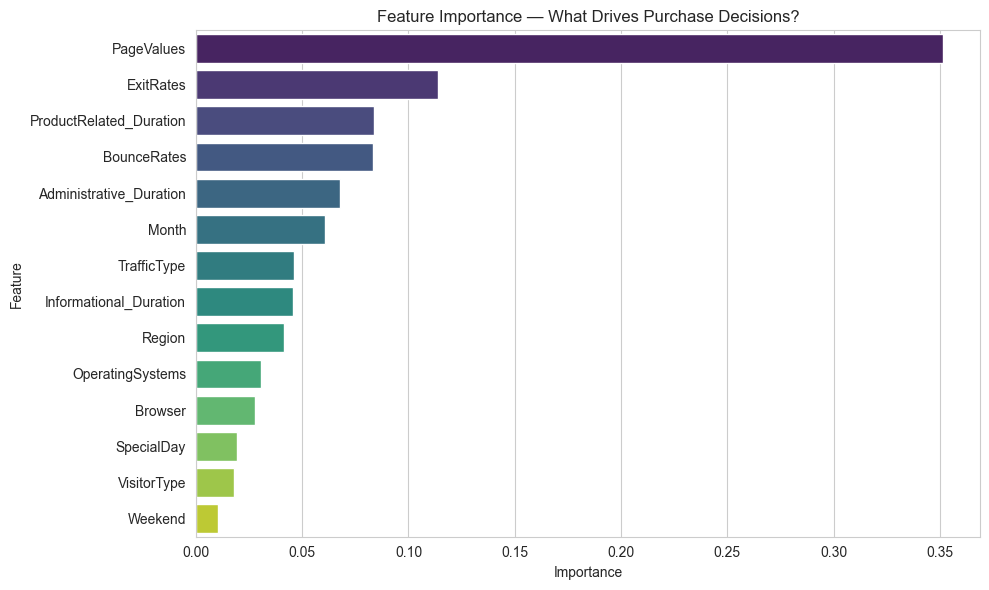

Top 5 features driving purchase decisions:
                   Feature  Importance
5               PageValues    0.351310
4                ExitRates    0.113669
2  ProductRelated_Duration    0.083831
3              BounceRates    0.083283
0  Administrative_Duration    0.067769


In [10]:
# Which features matter most for predicting purchases?
# This is the insight that's useful for business decisions

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': et.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance — What Drives Purchase Decisions?')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

print("Top 5 features driving purchase decisions:")
print(feature_importance.head())

In [11]:
# Project Summary — key numbers for the README and resume
print("=" * 50)
print("E-COMMERCE PURCHASE PREDICTION — KEY RESULTS")
print("=" * 50)
print(f"\nDataset: {df.shape[0]} sessions analysed")
print(f"Features used: {X.shape[1]}")
print(f"\nModels compared: 4")
print(f"  Logistic Regression: 84.2%")
print(f"  Decision Tree:       87.4%")
print(f"  Random Forest:       92.2%")
print(f"  Extra Trees:         93.9% (selected)")
print(f"\nFinal model accuracy: 93.9%")
print(f"Precision: 94%")
print(f"Recall: 94%")
print(f"F1-Score: 94%")
print(f"\nTop purchase predictor: PageValues (35.1% importance)")
print(f"Class imbalance handled using: SMOTE")
print("=" * 50)

# Save summary
with open('../outputs/key_results.txt', 'w') as f:
    f.write("E-COMMERCE PURCHASE PREDICTION - KEY RESULTS\n")
    f.write("=" * 50 + "\n")
    f.write(f"Dataset: {df.shape[0]} sessions analysed\n")
    f.write(f"Final model: Extra Trees Classifier\n")
    f.write(f"Accuracy: 93.9%\n")
    f.write(f"Top predictor: PageValues (35.1% importance)\n")

print("Summary saved to outputs/key_results.txt")

E-COMMERCE PURCHASE PREDICTION — KEY RESULTS

Dataset: 12157 sessions analysed
Features used: 14

Models compared: 4
  Logistic Regression: 84.2%
  Decision Tree:       87.4%
  Random Forest:       92.2%
  Extra Trees:         93.9% (selected)

Final model accuracy: 93.9%
Precision: 94%
Recall: 94%
F1-Score: 94%

Top purchase predictor: PageValues (35.1% importance)
Class imbalance handled using: SMOTE
Summary saved to outputs/key_results.txt
